# OOD Detection với MSP — CIFAR-10 (ID) vs CIFAR-100 & MNIST-C (OOD)

**Phương pháp:** Maximum Softmax Probability (Hendrycks & Gimpel, 2017) — baseline kinh điển của OOD detection.

**Thiết lập thực nghiệm**

| | Dataset | Số ảnh | Vai trò |
|---|---|---|---|
| ID | CIFAR-10 test | 10.000 | dữ liệu model được train để nhận |
| OOD 1 | CIFAR-100 test | 10.000 | **near-OOD** — ảnh tự nhiên 32×32, nhiều lớp gần nghĩa với CIFAR-10 |
| OOD 2 | MNIST-C test | 16 × 10.000 | **far-OOD** — chữ số viết tay, grayscale, 16 loại nhiễu |

**Model:** WideResNet-40-2 pretrained trên CIFAR-10 bằng cross-entropy (checkpoint của `energy_ood`, lấy qua `pytorch-ood`).

**Mục tiêu của bài:** so sánh MSP ở hai mức độ khó. Near-OOD (CIFAR-100) khó vì model vẫn "tự tin" trên ảnh tự nhiên tương tự; far-OOD (MNIST-C) lẽ ra phải dễ hơn nhiều.

---

> ⚠️ **Trước khi chạy: bật GPU.** `Runtime` → `Change runtime type` → `T4 GPU`.
>
> Chạy đủ 16 corruption của MNIST-C là 160.000 ảnh: trên GPU mất vài phút, trên CPU có thể hơn một tiếng.
> Nếu buộc phải dùng CPU, đặt `N_PER_SUBSET = 2000` ở cell cấu hình bên dưới.
>
> Notebook tải khoảng 700 MB dữ liệu: CIFAR-10, CIFAR-100, và `mnist_c.zip` (~340 MB, từ Zenodo).

In [ ]:
# ============================================================
# CELL 1: CÀI THƯ VIỆN
# ============================================================
!pip install -q pytorch-ood

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 474.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.2/473.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 9.5 MB/s eta 0:00:00


## 1. Import và cấu hình

Gom toàn bộ tham số về một chỗ, để chỉ cần sửa ở đây chứ không phải lần vào từng cell.

In [ ]:
# ============================================================
# CELL 2: IMPORT + CẤU HÌNH
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR10, CIFAR100
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from IPython.display import display

# ------------------------------------------------------------
# Cấu hình
# ------------------------------------------------------------
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT   = "./data"
BATCH_SIZE  = 256
NUM_WORKERS = 2

# Số ảnh dùng cho MỖI corruption của MNIST-C:
#   None -> dùng đủ 10.000 ảnh (chuẩn, nên dùng khi có GPU)
#   2000 -> chạy nhanh để thử, dùng khi chỉ có CPU
N_PER_SUBSET = None

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

# Bảng kết quả có 8 cột -> đừng để pandas cắt bớt
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("Device      :", DEVICE)

if DEVICE.type == "cuda":
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("\n⚠️  Đang chạy CPU. Nên bật GPU, hoặc đặt N_PER_SUBSET = 2000.")

PyTorch     : 2.11.0+cu130
Torchvision : 0.26.0+cu130
Device      : cuda
GPU         : Tesla T4


## 2. Load model pretrained

`load_transform()` trả về đúng bộ preprocessing mà checkpoint này được train với. Dùng lại chính nó cho mọi dataset là cách chắc chắn nhất để preprocessing không bị lệch — nếu tự gõ `mean`/`std` bằng tay mà sai một chút thì accuracy và toàn bộ điểm MSP đều lệch theo.

In [ ]:
# ============================================================
# CELL 3: LOAD WIDERESNET-40-2 PRETRAINED
# ============================================================

from pytorch_ood.model import load_model, load_transform

MODEL_ID = "wrn-40-2/cifar10/crossentropy"

model = load_model(MODEL_ID).to(DEVICE)
model.eval()

# Preprocessing gốc của checkpoint -> dùng chung cho CIFAR-10 và CIFAR-100
base_transform = load_transform(MODEL_ID)

print("Model      :", type(model).__name__)
print("Device     :", next(model.parameters()).device)
print("Parameters :", f"{sum(p.numel() for p in model.parameters()):,}")
print("\nPreprocessing cho ảnh RGB 32x32:")
print(base_transform)

Downloading: "https://github.com/wetliu/energy_ood/raw/master/CIFAR/snapshots/pretrained/cifar10_wrn_pretrained_epoch_99.pt" to /root/.cache/torch/hub/checkpoints/wrn-40-2-cifar10-crossentropy-0b59e178577382a0.pt


100%|██████████| 8.62M/8.62M [00:00<00:00, 62.9MB/s]


Model      : WideResNet
Device     : cuda:0
Parameters : 2,243,546

Preprocessing cho ảnh RGB 32x32:
Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.4913725490196078, 0.4823529411764706, 0.4466666666666667], std=[0.24705882352941178, 0.24352941176470588, 0.2615686274509804])
)


## 3. Hàm dùng chung

Ba thao tác lặp lại suốt notebook — tạo DataLoader, tính accuracy, tính điểm MSP — được gói thành hàm. Nhờ vậy CIFAR-10, CIFAR-100 và cả 16 subset MNIST-C đều đi qua **đúng một đường code**, không có nguy cơ copy-paste rồi quên sửa một chỗ.

**Công thức MSP.** Với logits $z$ của một ảnh $x$:

$$\mathrm{MSP}(x) \;=\; \max_{k}\ \mathrm{softmax}(z)_k \;=\; \max_k \frac{e^{z_k}}{\sum_j e^{z_j}}$$

MSP là **độ tự tin** của model. Giả thiết: ảnh ID → model tự tin → MSP cao; ảnh OOD → model lưỡng lự → MSP thấp.

Vậy **MSP cao nghĩa là "giống ID"**. Các metric OOD lại quy ước điểm cao = OOD, nên MSP phải *đảo dấu* trước khi đưa vào tính. Đây là chỗ dễ sai nhất của cả bài, nên Cell 13 sẽ đối chiếu lại với thư viện để kiểm tra.

In [ ]:
# ============================================================
# CELL 4: HÀM DÙNG CHUNG
# ============================================================

def make_loader(dataset):
    """DataLoader chuẩn cho mọi dataset (không shuffle, để kết quả tái lập được)."""
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )


@torch.no_grad()
def compute_accuracy(dataset):
    """Classification accuracy (%) — chỉ dùng cho ID, để kiểm tra model load đúng."""
    model.eval()
    correct = total = 0

    for images, labels in make_loader(dataset):
        preds = model(images.to(DEVICE, non_blocking=True)).argmax(dim=1).cpu()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / total


@torch.no_grad()
def compute_msp(dataset, name=""):
    """
    Trả về mảng numpy chứa điểm MSP của từng ảnh trong dataset.

    MSP cao  -> model tự tin   -> có xu hướng là ID
    MSP thấp -> model lưỡng lự -> có xu hướng là OOD
    """
    model.eval()
    chunks = []

    for images, _ in make_loader(dataset):
        logits = model(images.to(DEVICE, non_blocking=True))
        probs = F.softmax(logits, dim=1)
        chunks.append(probs.max(dim=1).values.cpu())

    scores = torch.cat(chunks).numpy()

    if name:
        print(f"{name:<34} n={len(scores):>6}   "
              f"mean={scores.mean():.4f}   median={np.median(scores):.4f}")

    return scores


def subsample(dataset, n):
    """Lấy n ảnh ngẫu nhiên (seed cố định) — dùng khi muốn chạy nhanh trên CPU."""
    if n is None or n >= len(dataset):
        return dataset

    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(len(dataset), generator=g)[:n].tolist()
    return Subset(dataset, idx)


print("Đã định nghĩa: make_loader, compute_accuracy, compute_msp, subsample")

Đã định nghĩa: make_loader, compute_accuracy, compute_msp, subsample


## 4. Dataset ID: CIFAR-10

Accuracy ở đây là **kiểm tra điều kiện tiên quyết**, không phải mục tiêu của bài: checkpoint `wrn-40-2` này công bố khoảng 94.8%. Nếu con số in ra khớp thì model và preprocessing đều đúng. Nếu lệch nhiều (ví dụ 10% hay 60%) thì transform đang sai, và mọi điểm MSP phía sau đều vô nghĩa.

In [ ]:
# ============================================================
# CELL 5: LOAD CIFAR-10 TEST (ID) + KIỂM TRA MODEL
# ============================================================

cifar10_test = CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=base_transform,
)

print("Số ảnh ID :", len(cifar10_test))
print("Số lớp    :", len(cifar10_test.classes))
print("Các lớp   :", cifar10_test.classes)

acc = compute_accuracy(cifar10_test)

print(f"\nAccuracy trên CIFAR-10 test: {acc:.2f}%")
print("Tham chiếu: checkpoint này công bố ~94.8% -> model + preprocessing OK.")

100%|██████████| 170M/170M [00:50<00:00, 3.36MB/s]


Số ảnh ID : 10000
Số lớp    : 10
Các lớp   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Accuracy trên CIFAR-10 test: 94.84%
Tham chiếu: checkpoint này công bố ~94.8% -> model + preprocessing OK.


## 5. Dataset OOD 1: CIFAR-100 (near-OOD)

CIFAR-100 dùng **chung `base_transform`** với CIFAR-10, vì cùng là ảnh RGB 32×32.

Về khái niệm: CIFAR-100 không trùng lớp nào với CIFAR-10, nhưng rất gần về phân phối ảnh — cùng độ phân giải, cùng kiểu ảnh tự nhiên, và nhiều lớp thuộc cùng nhóm ngữ nghĩa (`leopard` / `tiger` so với `cat`, `pickup_truck` so với `truck`). Đó là lý do near-OOD khó.

In [ ]:
# ============================================================
# CELL 6: LOAD CIFAR-100 TEST (OOD gần)
# ============================================================

cifar100_test = CIFAR100(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=base_transform,
)

print("Số ảnh OOD (CIFAR-100):", len(cifar100_test))
print("Số lớp                :", len(cifar100_test.classes))
print("20 lớp đầu            :", cifar100_test.classes[:20])

100%|██████████| 169M/169M [00:32<00:00, 5.24MB/s]


Số ảnh OOD (CIFAR-100): 10000
Số lớp                : 100
20 lớp đầu            : ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle']


## 6. Dataset OOD 2: MNIST-C (far-OOD)

MNIST-C (Mu & Gilmer, 2019) là MNIST với **16 loại nhiễu**, mỗi loại 10.000 ảnh test.

**Vấn đề định dạng cần xử lý.** MNIST-C không thể đưa trực tiếp vào model CIFAR-10:

| | MNIST-C | Model cần |
|---|---|---|
| Kích thước | 28 × 28 | 32 × 32 |
| Số kênh | 1 — grayscale, PIL mode `"L"` | 3 — RGB |

Nên phải thêm hai bước **trước** `base_transform`:

1. `Resize((32, 32))` — khớp kích thước đầu vào.
2. `Grayscale(num_output_channels=3)` — nhân kênh xám thành 3 kênh giống nhau.

Rồi **nối tiếp chính `base_transform`** vào sau. Đây là điểm quan trọng: không gõ lại `Normalize(mean=..., std=...)` bằng tay, mà tái sử dụng đúng object đã dùng cho CIFAR-10. Như vậy cả ba dataset được chuẩn hoá **y hệt nhau** — điều kiện bắt buộc để so sánh điểm MSP giữa chúng cho có nghĩa.

Một lưu ý nữa: `MNISTC` trả về nhãn là **chữ số 0–9**, không phải `-1`. Notebook này không dùng nhãn của tập OOD (nhãn ID/OOD được tạo riêng ở hàm đánh giá), nên không cần `ToUnknown()`.

In [ ]:
# ============================================================
# CELL 7: TRANSFORM CHO MNIST-C + TẢI DỮ LIỆU
# ============================================================

from pytorch_ood.dataset.img import MNISTC

# 16 loại nhiễu của MNIST-C
MNISTC_ALL_SUBSETS = [
    "brightness",    "canny_edges", "dotted_line", "fog",
    "glass_blur",    "identity",    "impulse_noise", "motion_blur",
    "rotate",        "scale",       "shear",       "shot_noise",
    "spatter",       "stripe",      "translate",   "zigzag",
]

# Muốn chạy nhanh thì rút ngắn danh sách này, ví dụ:
# MNISTC_SUBSETS = ["identity", "fog", "glass_blur", "zigzag"]
MNISTC_SUBSETS = MNISTC_ALL_SUBSETS

# 28x28 grayscale -> 32x32 -> 3 kênh -> CHÍNH base_transform của CIFAR-10
mnistc_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    base_transform,
])

# Lần gọi đầu tiên tải mnist_c.zip (~340 MB) từ Zenodo rồi giải nén.
# File zip chứa sẵn cả 16 corruption, nên các cell sau chỉ cần download=False.
probe = MNISTC(
    root=DATA_ROOT,
    subset="identity",
    split="test",
    transform=mnistc_transform,
    download=True,
)

img, target = probe[0]

print("MNIST-C đã sẵn sàng.")
print("Số ảnh mỗi corruption :", len(probe))
print("Shape sau transform   :", tuple(img.shape), "| dtype:", img.dtype)
print("Nhãn trả về           :", target, "(chữ số 0-9, KHÔNG phải -1)")

assert tuple(img.shape) == (3, 32, 32), "Transform sai: shape không khớp model!"
print("\n-> Shape (3, 32, 32) khớp đầu vào WideResNet. Transform đúng.")

100%|██████████| 247M/247M [01:36<00:00, 2.55MB/s]


MNIST-C đã sẵn sàng.
Số ảnh mỗi corruption : 10000
Shape sau transform   : (3, 32, 32) | dtype: torch.float32
Nhãn trả về           : 7 (chữ số 0-9, KHÔNG phải -1)

-> Shape (3, 32, 32) khớp đầu vào WideResNet. Transform đúng.


### Xem thử dữ liệu sau tiền xử lý

Bước này để **mắt thường xác nhận** preprocessing không làm hỏng ảnh — ví dụ resize gây méo, hay ảnh bị đen hết. Hiển thị ở dạng chưa normalize cho dễ nhìn.

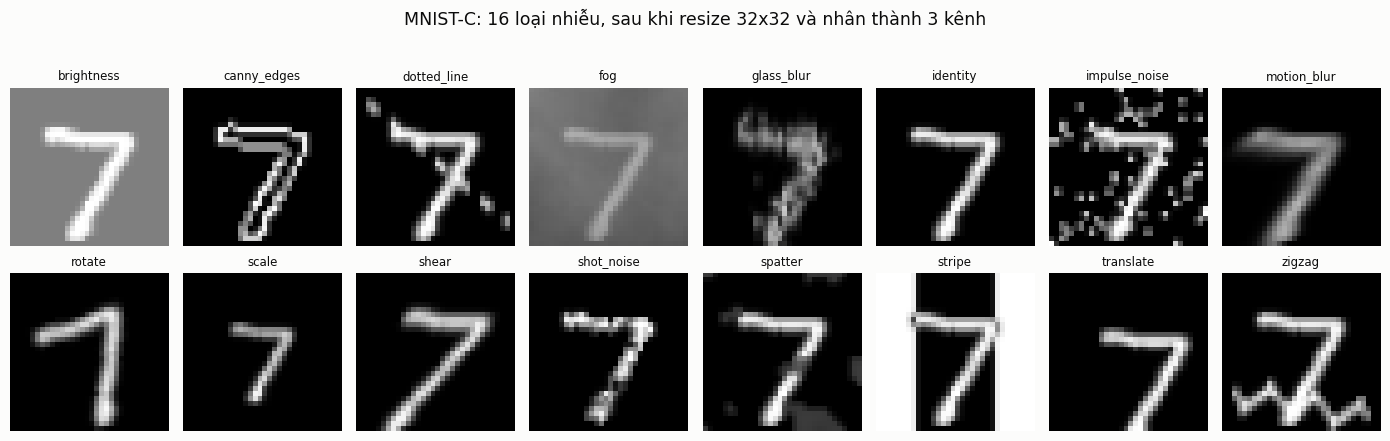

In [ ]:
# ============================================================
# CELL 8: HIỂN THỊ 16 LOẠI NHIỄU CỦA MNIST-C
# ============================================================

SURFACE   = "#fcfcfb"   # nền hình
INK       = "#0b0b0b"   # chữ chính
INK_MUTED = "#52514e"   # chữ phụ
GRID      = "#e5e4e0"   # lưới / trục

# Chỉ resize + đổi kênh, KHÔNG normalize, để ảnh hiện đúng như mắt thấy
display_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
])

fig, axes = plt.subplots(2, 8, figsize=(14, 4.4))
fig.patch.set_facecolor(SURFACE)

for ax, subset in zip(axes.ravel(), MNISTC_ALL_SUBSETS):
    ds = MNISTC(root=DATA_ROOT, subset=subset, split="test",
                transform=display_transform, download=False)
    ax.imshow(ds[0][0])
    ax.set_title(subset, fontsize=8.5, color=INK)
    ax.axis("off")

fig.suptitle("MNIST-C: 16 loại nhiễu, sau khi resize 32x32 và nhân thành 3 kênh",
             fontsize=12.5, color=INK, y=1.03)
plt.tight_layout()
plt.show()

## 7. Tính điểm MSP

Chạy model một lượt qua từng dataset và lưu lại MSP của mọi ảnh. Đây là phần tốn thời gian nhất.

In [ ]:
# ============================================================
# CELL 9: MSP CHO ID VÀ CIFAR-100
# ============================================================

id_msp   = compute_msp(cifar10_test,  "ID  CIFAR-10")
c100_msp = compute_msp(cifar100_test, "OOD CIFAR-100")

ID  CIFAR-10                       n= 10000   mean=0.9766   median=0.9999
OOD CIFAR-100                      n= 10000   mean=0.8321   median=0.9157


In [ ]:
# ============================================================
# CELL 10: MSP CHO 16 CORRUPTION CỦA MNIST-C
# ============================================================

mnistc_msp = {}

for subset in MNISTC_SUBSETS:
    ds = MNISTC(root=DATA_ROOT, subset=subset, split="test",
                transform=mnistc_transform, download=False)
    ds = subsample(ds, N_PER_SUBSET)
    mnistc_msp[subset] = compute_msp(ds, f"OOD MNIST-C / {subset}")

# Gộp 16 corruption thành một tập MNIST-C duy nhất, để có con số tổng
mnistc_all_msp = np.concatenate([mnistc_msp[s] for s in MNISTC_SUBSETS])

print(f"\nTổng số ảnh MNIST-C : {len(mnistc_all_msp):,}")
print(f"MSP trung bình      : {mnistc_all_msp.mean():.4f}")

OOD MNIST-C / brightness           n= 10000   mean=0.7833   median=0.8372
OOD MNIST-C / canny_edges          n= 10000   mean=0.6830   median=0.6908
OOD MNIST-C / dotted_line          n= 10000   mean=0.6927   median=0.7010
OOD MNIST-C / fog                  n= 10000   mean=0.7691   median=0.8114
OOD MNIST-C / glass_blur           n= 10000   mean=0.6661   median=0.6733
OOD MNIST-C / identity             n= 10000   mean=0.7746   median=0.8333
OOD MNIST-C / impulse_noise        n= 10000   mean=0.6252   median=0.6050
OOD MNIST-C / motion_blur          n= 10000   mean=0.7440   median=0.7756
OOD MNIST-C / rotate               n= 10000   mean=0.7891   median=0.8500
OOD MNIST-C / scale                n= 10000   mean=0.7953   median=0.8764
OOD MNIST-C / shear                n= 10000   mean=0.8003   median=0.8713
OOD MNIST-C / shot_noise           n= 10000   mean=0.6972   median=0.7171
OOD MNIST-C / spatter              n= 10000   mean=0.7414   median=0.7691
OOD MNIST-C / stripe               n= 

In [ ]:
# ============================================================
# CELL 11: THỐNG KÊ PHÂN PHỐI MSP
# ============================================================

def describe(scores, name):
    return {
        "Dataset":  name,
        "n":        len(scores),
        "Mean":     scores.mean(),
        "Median":   np.median(scores),
        "Std":      scores.std(),
        "Min":      scores.min(),
        "Max":      scores.max(),
        "% > 0.99": 100.0 * (scores > 0.99).mean(),
    }

stats_df = pd.DataFrame([
    describe(id_msp,         "CIFAR-10  (ID)"),
    describe(c100_msp,       "CIFAR-100 (near-OOD)"),
    describe(mnistc_all_msp, "MNIST-C   (far-OOD)"),
])

print("Phân phối điểm MSP\n")
display(stats_df.round(4))

print("\nCột '% > 0.99': model tự tin gần như tuyệt đối trên bao nhiêu phần trăm ảnh.")
print("Tỉ lệ này ở OOD càng cao thì MSP càng khó tách — đó chính là điểm yếu của MSP.")

Phân phối điểm MSP



,Dataset,n,Mean,Median,Std,Min,Max,% > 0.99
0,CIFAR-10 (ID),10000,0.9766,0.9999,0.0814,0.3000,1.0,85.4100
1,CIFAR-100 (near-OOD),10000,0.8321,0.9157,0.1871,0.2239,1.0,25.9200
2,MNIST-C (far-OOD),160000,0.7355,0.7703,0.2126,0.1478,1.0,8.8881



Cột '% > 0.99': model tự tin gần như tuyệt đối trên bao nhiêu phần trăm ảnh.
Tỉ lệ này ở OOD càng cao thì MSP càng khó tách — đó chính là điểm yếu của MSP.


## 8. Năm metric đánh giá

Notebook báo cáo đủ **5 metric** cho từng bộ dữ liệu test, đúng bộ mà `pytorch_ood.utils.OODMetrics` trả về. Mọi metric đều quy ước **điểm cao = OOD**, nên MSP phải đảo dấu trước khi đưa vào.

| Metric | Ý nghĩa | Chiều tốt |
|---|---|---|
| **AUROC** | Xác suất một ảnh OOD ngẫu nhiên được chấm "OOD hơn" một ảnh ID ngẫu nhiên. 50% là đoán bừa, 100% là tách hoàn hảo. Không phụ thuộc ngưỡng, không bị ảnh hưởng bởi tỉ lệ ID/OOD. | ↑ cao |
| **AUPR-IN** | Average precision khi coi **ID** là lớp dương. | ↑ cao |
| **AUPR-OUT** | Average precision khi coi **OOD** là lớp dương. | ↑ cao |
| **FPR95TPR** | Tỉ lệ ảnh ID bị gắn nhãn OOD oan, tại ngưỡng bắt được 95% ảnh OOD. Đây là chỉ số sát với thực tế dùng nhất. | ↓ thấp |
| **AUTC** | *Area Under the Threshold Curve* — trung bình của FPR và FNR trên mọi ngưỡng, sau khi co điểm về đoạn [0, 1]. Khác AUROC ở chỗ nó phản ánh cả **khoảng cách** giữa hai phân phối điểm, chứ không chỉ thứ hạng. Bằng 0 là hoàn hảo. | ↓ thấp |

**Hai lưu ý khi đọc bảng:**

- **AUPR-IN / AUPR-OUT phụ thuộc tỉ lệ ID/OOD**, nên chỉ so hai chỉ số này giữa các dòng có **cùng số lượng mẫu**. Dòng MNIST-C gộp có 160.000 ảnh OOD so với 10.000 ảnh ID, nên AUPR-OUT của nó bị đẩy lên cao một cách máy móc — không so trực tiếp với dòng CIFAR-100 được. AUROC, FPR95TPR và AUTC thì không gặp vấn đề này.
- **AUTC co điểm về [0, 1] bằng min–max**, nên nó nhạy với giá trị cực trị của thang điểm.

In [ ]:
# ============================================================
# CELL 12: HÀM TÍNH METRIC BẰNG SKLEARN
# Dùng để: (a) lấy dữ liệu vẽ đường ROC
#          (b) đối chiếu chéo với pytorch-ood ở Cell 13
# ============================================================

def evaluate_ood(id_scores, ood_scores):
    """
    id_scores / ood_scores: điểm MSP (cao = giống ID).

    Quy ước của metric: điểm cao = OOD, nhãn ID=0 / OOD=1.
    MSP ngược chiều nên dùng -MSP làm điểm.
    """
    y_true  = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_score = np.concatenate([-id_scores, -ood_scores])

    fpr, tpr, _ = roc_curve(y_true, y_score)

    # FPR tại điểm đầu tiên có TPR >= 95%
    # (tpr không giảm, nên argmax lấy đúng điểm đầu tiên thoả điều kiện)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]

    return {
        "AUROC":    roc_auc_score(y_true, y_score),
        "FPR95":    fpr95,
        "AUPR-IN":  average_precision_score(1 - y_true, -y_score),  # ID là lớp dương
        "AUPR-OUT": average_precision_score(y_true, y_score),       # OOD là lớp dương
        "_fpr":     fpr,
        "_tpr":     tpr,
    }


res_c100   = evaluate_ood(id_msp, c100_msp)
res_mnistc = evaluate_ood(id_msp, mnistc_all_msp)

print("Đã tính metric cho cả hai tập OOD.")

Đã tính metric cho cả hai tập OOD.


In [ ]:
# ============================================================
# CELL 13: TÍNH ĐỦ 5 METRIC BẰNG OODMetrics
# Đây là nguồn số liệu chính cho các bảng kết quả bên dưới.
# ============================================================

from pytorch_ood.utils import OODMetrics

# Thứ tự hiển thị 5 metric trong mọi bảng
METRIC_KEYS = ["AUROC", "AUPR-IN", "AUPR-OUT", "FPR95TPR", "AUTC"]

# Chiều tốt của từng metric, dùng để ghi chú trên đầu cột
HIGHER_IS_BETTER = {"AUROC": True, "AUPR-IN": True, "AUPR-OUT": True,
                    "FPR95TPR": False, "AUTC": False}


def evaluate_5_metrics(id_scores, ood_scores):
    """
    Trả về dict đủ 5 metric cho một cặp (ID, OOD).

    pytorch-ood quy ước: điểm cao = OOD, nhãn ID >= 0 và OOD < 0.
    MSP cao = ID, nên phải đưa vào -MSP.
    """
    metrics = OODMetrics()
    metrics.update(
        torch.tensor(-np.concatenate([id_scores, ood_scores]), dtype=torch.float32),
        torch.tensor(
            np.concatenate([np.zeros(len(id_scores)), -np.ones(len(ood_scores))]),
            dtype=torch.long,
        ),
    )
    raw = metrics.compute()
    return {k: float(raw.get(k, float("nan"))) for k in METRIC_KEYS}, raw


m_c100, raw_c100   = evaluate_5_metrics(id_msp, c100_msp)
m_mnistc, _        = evaluate_5_metrics(id_msp, mnistc_all_msp)

print("Các metric OODMetrics trả về :", list(raw_c100.keys()))
print("Các metric notebook báo cáo  :", METRIC_KEYS)

missing = [k for k in METRIC_KEYS if k not in raw_c100]
if missing:
    print(f"\n⚠️  Phiên bản pytorch-ood này không có: {missing} (sẽ hiện NaN).")

# ------------------------------------------------------------
# Đối chiếu chéo với sklearn (Cell 12) để chắc chắn không sai dấu
# ------------------------------------------------------------
print("\nĐối chiếu trên CIFAR-100 — sklearn (Cell 12) vs pytorch-ood\n")
print(f"{'Metric':<12}{'sklearn':>12}{'pytorch-ood':>14}")
print("-" * 38)

for mine, theirs in [("AUROC", "AUROC"), ("FPR95", "FPR95TPR"),
                     ("AUPR-IN", "AUPR-IN"), ("AUPR-OUT", "AUPR-OUT")]:
    print(f"{mine:<12}{res_c100[mine]:>12.4f}{m_c100[theirs]:>14.4f}")

print(f"{'AUTC':<12}{'—':>12}{m_c100['AUTC']:>14.4f}   (sklearn không có AUTC)")

assert abs(res_c100["AUROC"] - m_c100["AUROC"]) < 1e-4, "Lệch AUROC — kiểm tra lại dấu!"
assert abs(res_c100["FPR95"] - m_c100["FPR95TPR"]) < 1e-3, "Lệch FPR95!"
print("\n-> Hai cách tính khớp nhau. Quy ước dấu đúng.")

Các metric OODMetrics trả về : ['AUROC', 'AUTC', 'AUPR-IN', 'AUPR-OUT', 'FPR95TPR']
Các metric notebook báo cáo  : ['AUROC', 'AUPR-IN', 'AUPR-OUT', 'FPR95TPR', 'AUTC']

Đối chiếu trên CIFAR-100 — sklearn (Cell 12) vs pytorch-ood

Metric           sklearn   pytorch-ood
--------------------------------------
AUROC             0.8783        0.8783
FPR95             0.4308        0.4308
AUPR-IN           0.8842        0.8842
AUPR-OUT          0.8521        0.8520
AUTC                   —        0.4069   (sklearn không có AUTC)

-> Hai cách tính khớp nhau. Quy ước dấu đúng.


## 9. Kết quả

In [ ]:
# ============================================================
# CELL 14: BẢNG 5 METRIC CHO TỪNG BỘ DỮ LIỆU TEST
# ============================================================

def metric_columns(metrics):
    """Đổi dict 5 metric thành các cột %, kèm mũi tên chỉ chiều tốt."""
    cols = {}
    for k in METRIC_KEYS:
        arrow = "↑" if HIGHER_IS_BETTER[k] else "↓"
        cols[f"{k} {arrow} (%)"] = 100 * metrics[k]
    return cols


results_df = pd.DataFrame([
    {"Tập dữ liệu test": "CIFAR-100 (near-OOD)",
     "n OOD": len(c100_msp), **metric_columns(m_c100)},
    {"Tập dữ liệu test": "MNIST-C, gộp 16 corruption (far-OOD)",
     "n OOD": len(mnistc_all_msp), **metric_columns(m_mnistc)},
])

print("5 METRIC CỦA MSP — WideResNet-40-2 / CIFAR-10")
print(f"ID: CIFAR-10 test, n={len(id_msp)}, accuracy {acc:.2f}%\n")
display(results_df.round(2))

print("\n↑ càng cao càng tốt: AUROC, AUPR-IN, AUPR-OUT")
print("↓ càng thấp càng tốt: FPR95TPR, AUTC")
print("\nHai dòng có n OOD khác nhau, nên AUPR-IN / AUPR-OUT KHÔNG so chéo được")
print("giữa hai dòng. AUROC, FPR95TPR và AUTC thì so trực tiếp bình thường.")

5 METRIC CỦA MSP — WideResNet-40-2 / CIFAR-10
ID: CIFAR-10 test, n=10000, accuracy 94.84%



,Tập dữ liệu test,n OOD,AUROC ↑ (%),AUPR-IN ↑ (%),AUPR-OUT ↑ (%),FPR95TPR ↓ (%),AUTC ↓ (%)
0,CIFAR-100 (near-OOD),10000,87.83,88.42,85.20,43.08,40.69
1,"MNIST-C, gộp 16 corruption (far-OOD)",160000,94.07,79.67,99.46,18.51,35.86



↑ càng cao càng tốt: AUROC, AUPR-IN, AUPR-OUT
↓ càng thấp càng tốt: FPR95TPR, AUTC

Hai dòng có n OOD khác nhau, nên AUPR-IN / AUPR-OUT KHÔNG so chéo được
giữa hai dòng. AUROC, FPR95TPR và AUTC thì so trực tiếp bình thường.


In [ ]:
# ============================================================
# CELL 15: KẾT QUẢ CHI TIẾT THEO TỪNG CORRUPTION
# ============================================================

per_subset = []

for subset in MNISTC_SUBSETS:
    m, _ = evaluate_5_metrics(id_msp, mnistc_msp[subset])
    per_subset.append({
        "Corruption": subset,
        "n":          len(mnistc_msp[subset]),
        "MSP mean":   mnistc_msp[subset].mean(),
        **metric_columns(m),
    })

AUROC_COL = "AUROC ↑ (%)"

per_subset_df = (pd.DataFrame(per_subset)
                 .sort_values(AUROC_COL, ascending=False)
                 .reset_index(drop=True))

print("5 METRIC TRÊN TỪNG LOẠI NHIỄU CỦA MNIST-C")
print("(mỗi dòng so 10.000 ảnh corruption đó với cùng 10.000 ảnh ID,")
print(" nên n cân bằng và cả 5 metric đều so chéo giữa các dòng được)\n")
display(per_subset_df.round(2))

print(f"\nAUROC trung bình trên {len(per_subset_df)} corruption : "
      f"{per_subset_df[AUROC_COL].mean():.2f}%  "
      f"(std {per_subset_df[AUROC_COL].std():.2f})")
print(f"Dễ phát hiện nhất  : {per_subset_df.iloc[0]['Corruption']} "
      f"({per_subset_df.iloc[0][AUROC_COL]:.2f}%)")
print(f"Khó phát hiện nhất : {per_subset_df.iloc[-1]['Corruption']} "
      f"({per_subset_df.iloc[-1][AUROC_COL]:.2f}%)")

5 METRIC TRÊN TỪNG LOẠI NHIỄU CỦA MNIST-C
(mỗi dòng so 10.000 ảnh corruption đó với cùng 10.000 ảnh ID,
 nên n cân bằng và cả 5 metric đều so chéo giữa các dòng được)



,Corruption,n,MSP mean,AUROC ↑ (%),AUPR-IN ↑ (%),AUPR-OUT ↑ (%),FPR95TPR ↓ (%),AUTC ↓ (%)
0,impulse_noise,10000,0.63,96.90,97.61,96.08,10.65,28.57
1,canny_edges,10000,0.68,95.82,96.89,94.50,12.92,32.36
2,glass_blur,10000,0.67,95.70,96.69,94.68,14.16,31.78
3,dotted_line,10000,0.69,95.41,96.49,94.05,14.83,32.48
4,shot_noise,10000,0.70,95.33,96.50,93.92,14.12,33.20
5,stripe,10000,0.72,95.03,96.32,93.23,14.57,33.96
6,zigzag,10000,0.74,94.66,96.04,92.55,15.53,34.97
7,motion_blur,10000,0.74,94.41,95.86,92.20,16.46,34.81
8,spatter,10000,0.74,94.25,95.67,92.19,17.26,35.38
9,translate,10000,0.75,93.43,94.91,91.48,20.92,35.70



AUROC trung bình trên 16 corruption : 94.07%  (std 1.57)
Dễ phát hiện nhất  : impulse_noise (96.90%)
Khó phát hiện nhất : scale (91.84%)


## 10. Biểu đồ

Ba hình: phân phối điểm MSP, đường ROC, và AUROC theo từng loại nhiễu.

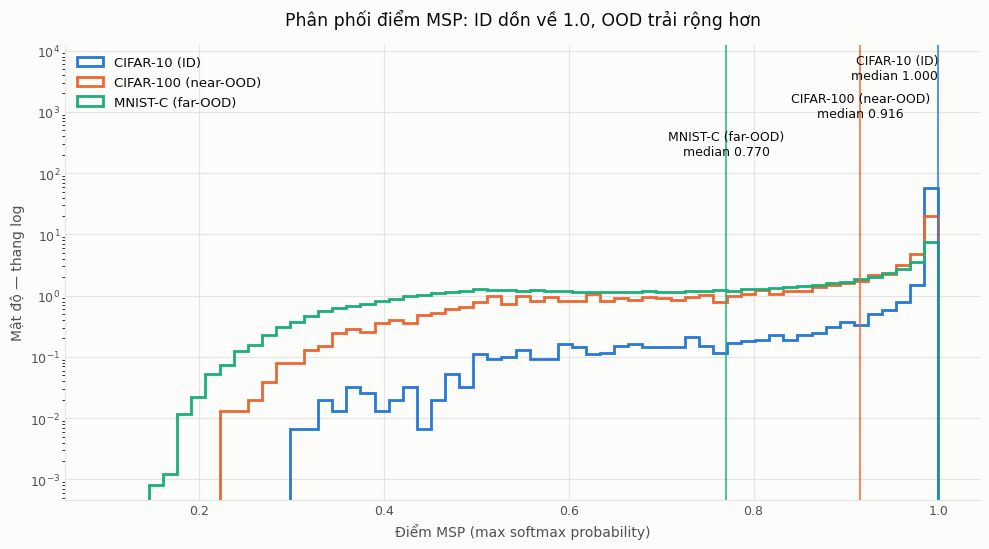

In [ ]:
# ============================================================
# CELL 16: PHÂN PHỐI ĐIỂM MSP
# ============================================================

# Màu cố định cho từng tập dữ liệu, dùng thống nhất ở mọi biểu đồ
C_ID     = "#2a78d6"   # xanh dương
C_C100   = "#eb6834"   # cam
C_MNISTC = "#1baf7a"   # xanh ngọc


def style_axes(ax):
    """Trục và lưới mờ, bỏ viền trên/phải."""
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, length=0, labelsize=9)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)


series = [
    ("CIFAR-10 (ID)",        id_msp,         C_ID),
    ("CIFAR-100 (near-OOD)", c100_msp,       C_C100),
    ("MNIST-C (far-OOD)",    mnistc_all_msp, C_MNISTC),
]

fig, ax = plt.subplots(figsize=(10, 5.6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

bins = np.linspace(0.1, 1.0, 60)

# Vẽ dạng đường viền thay vì cột tô màu: ba phân phối chồng nhau vẫn đọc được
for name, scores, color in series:
    ax.hist(scores, bins=bins, density=True, histtype="step",
            linewidth=2, color=color, label=name)

# MSP của ID dồn gần hết vào 1.0 -> thang log mới thấy được phần còn lại
ax.set_yscale("log")

# Chừa khoảng trống phía trên để đặt nhãn mà không đè lên đường cong
ydata_max = ax.get_ylim()[1]
ax.set_ylim(top=ydata_max * 10 ** 2.1)

# Nhãn trực tiếp tại median, xếp so le theo chiều cao trong vùng trống
for i, (name, scores, color) in enumerate(series):
    med = np.median(scores)
    ax.axvline(med, color=color, linewidth=1.5, alpha=0.75)
    ax.text(med, ydata_max * 10 ** (0.25 + 0.62 * (2 - i)),
            f"{name}\nmedian {med:.3f}",
            fontsize=9, color=INK, va="bottom",
            ha="right" if med > 0.93 else "center")

ax.set_xlabel("Điểm MSP (max softmax probability)", color=INK_MUTED, fontsize=10)
ax.set_ylabel("Mật độ — thang log", color=INK_MUTED, fontsize=10)
ax.set_title("Phân phối điểm MSP: ID dồn về 1.0, OOD trải rộng hơn",
             color=INK, fontsize=12.5, pad=14)
ax.legend(frameon=False, labelcolor=INK, fontsize=9.5, loc="upper left")

plt.tight_layout()
plt.show()

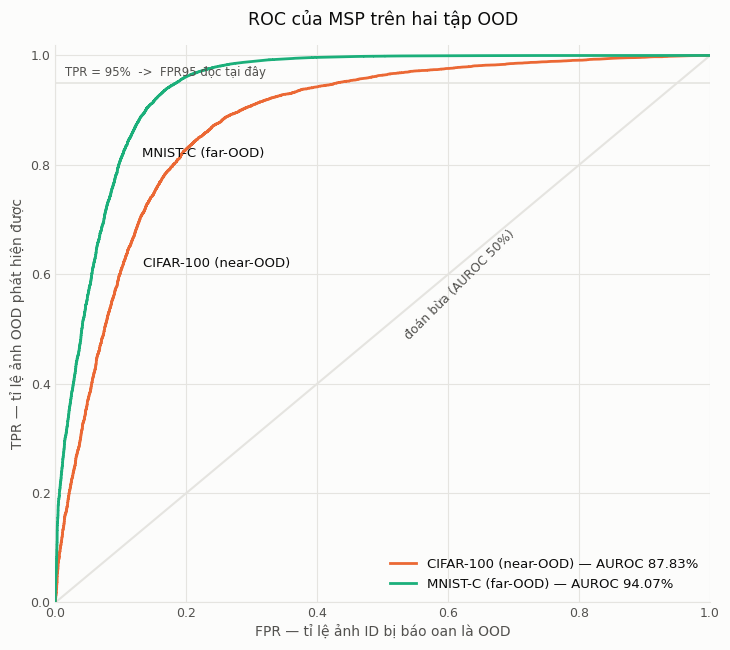

In [ ]:
# ============================================================
# CELL 17: ĐƯỜNG ROC
# ============================================================

fig, ax = plt.subplots(figsize=(7.4, 6.6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

# Đường chéo = bộ phát hiện đoán bừa
ax.plot([0, 1], [0, 1], color=GRID, linewidth=1.5, zorder=1)
ax.text(0.54, 0.48, "đoán bừa (AUROC 50%)", fontsize=9,
        color=INK_MUTED, rotation=45, rotation_mode="anchor")

# y_at: neo nhãn tại mức TPR này của mỗi đường cong.
# Neo theo TPR (không theo FPR) để nhãn luôn nằm trong khung dù đường cong dốc cỡ nào.
roc_series = [
    ("CIFAR-100 (near-OOD)", res_c100,   C_C100,   0.62),
    ("MNIST-C (far-OOD)",    res_mnistc, C_MNISTC, 0.82),
]

for name, res, color, y_at in roc_series:
    ax.plot(res["_fpr"], res["_tpr"], color=color, linewidth=2, zorder=3,
            label=f"{name} — AUROC {100 * res['AUROC']:.2f}%")

    # Nhãn trực tiếp, đặt ngay bên phải đường cong trong vùng trống
    j = np.argmax(res["_tpr"] >= y_at)
    ax.annotate(name, xy=(res["_fpr"][j], res["_tpr"][j]),
                xytext=(14, 0), textcoords="offset points",
                fontsize=9.5, color=INK, va="center", ha="left", zorder=4)

# Mốc TPR = 95%, là nơi đọc ra FPR95
ax.axhline(0.95, color=GRID, linewidth=1.2, zorder=2)
ax.text(0.015, 0.957, "TPR = 95%  ->  FPR95 đọc tại đây",
        fontsize=8.5, color=INK_MUTED, va="bottom")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("FPR — tỉ lệ ảnh ID bị báo oan là OOD", color=INK_MUTED, fontsize=10)
ax.set_ylabel("TPR — tỉ lệ ảnh OOD phát hiện được", color=INK_MUTED, fontsize=10)
ax.set_title("ROC của MSP trên hai tập OOD", color=INK, fontsize=12.5, pad=14)
ax.legend(frameon=False, labelcolor=INK, fontsize=9.5, loc="lower right")

plt.tight_layout()
plt.show()

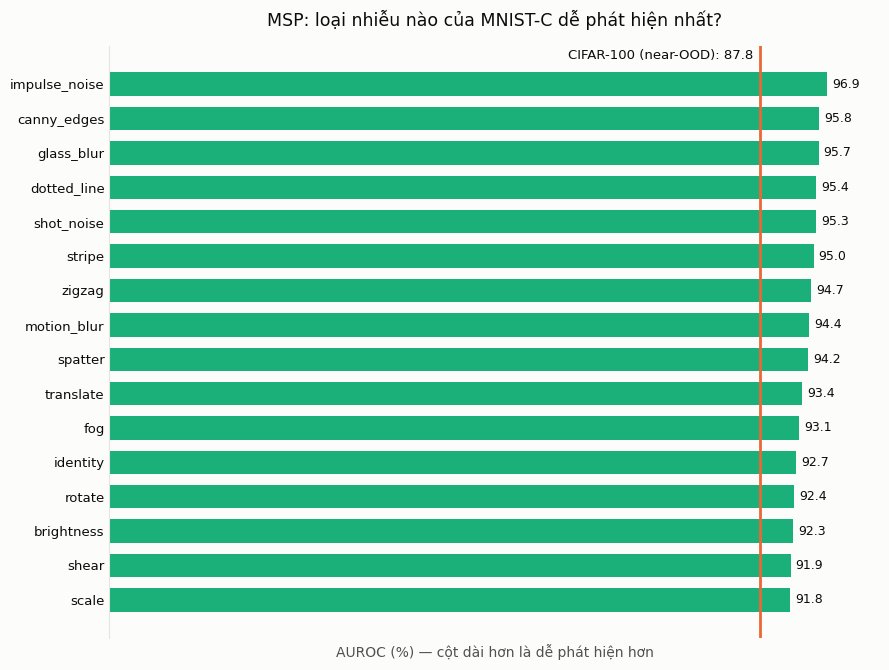

In [ ]:
# ============================================================
# CELL 18: AUROC THEO TỪNG LOẠI NHIỄU CỦA MNIST-C
# ============================================================

# Sắp thấp -> cao, loại khó nhất nằm dưới cùng
plot_df = per_subset_df.sort_values(AUROC_COL)

fig, ax = plt.subplots(figsize=(9, 6.8))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

# Nhãn giá trị ngay trên từng cột đã thay vai trò trục x -> bỏ trục x và lưới
ax.grid(False)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)

y = np.arange(len(plot_df))

# Một chuỗi dữ liệu -> một màu duy nhất cho mọi cột (không tô đậm theo giá trị)
ax.barh(y, plot_df[AUROC_COL], color=C_MNISTC, height=0.68)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Corruption"], fontsize=9.5, color=INK)

for yi, v in zip(y, plot_df[AUROC_COL]):
    ax.text(v + 0.7, yi, f"{v:.1f}", va="center", fontsize=9, color=INK)

# Mốc so sánh: AUROC trên CIFAR-100 (near-OOD)
auroc_c100 = 100 * m_c100["AUROC"]
ax.axvline(auroc_c100, color=C_C100, linewidth=2, zorder=3)
ax.text(auroc_c100 - 1.0, len(plot_df) - 0.35,
        f"CIFAR-100 (near-OOD): {auroc_c100:.1f}", fontsize=9.5, color=INK,
        ha="right", va="bottom")

ax.set_xlim(0, max(104, plot_df[AUROC_COL].max() + 7))
ax.set_xlabel("AUROC (%) — cột dài hơn là dễ phát hiện hơn",
              color=INK_MUTED, fontsize=10)
ax.set_title("MSP: loại nhiễu nào của MNIST-C dễ phát hiện nhất?",
             color=INK, fontsize=12.5, pad=14)

plt.tight_layout()
plt.show()

## 11. Nhận xét

*(Điền số liệu thật sau khi chạy xong.)*

**1. Model hoạt động đúng.** Accuracy trên CIFAR-10 test khớp con số công bố của checkpoint, nên mọi kết luận phía sau dựa trên một bộ phân loại tốt, chứ không phải một model bị load lỗi.

**2. Near-OOD khó hơn far-OOD.** So AUROC của CIFAR-100 với MNIST-C ở bảng Cell 14. CIFAR-100 khó hơn vì cùng miền ảnh tự nhiên 32×32 và chia sẻ nhiều khái niệm ngữ nghĩa với CIFAR-10 — biểu diễn bên trong mạng của một con `leopard` nằm rất gần một con `cat`, nên softmax vẫn dồn xác suất vào một lớp và MSP vẫn cao.

**3. Điểm yếu cốt lõi của MSP: quá tự tin.** Xem cột `% > 0.99` ở Cell 11. Softmax được huấn luyện bằng cross-entropy nên luôn bị đẩy về phân phối one-hot; nó chuẩn hoá trên **10 lớp CIFAR-10** và không có cách nào biểu diễn khái niệm "không thuộc lớp nào cả". Vì vậy ngay cả ảnh hoàn toàn xa lạ vẫn có thể nhận MSP gần 1.0. `FPR95TPR` cao chính là hệ quả trực tiếp: muốn bắt được 95% ảnh OOD thì phải hy sinh rất nhiều ảnh ID.

Đây cũng là chỗ **AUTC bổ sung thông tin mà AUROC không có**. AUROC chỉ nhìn thứ hạng, nên hai bộ phát hiện có cùng AUROC vẫn có thể rất khác nhau về mức độ tách rời của hai phân phối điểm. AUTC phạt trường hợp điểm ID và OOD tuy xếp đúng thứ tự nhưng nằm sát nhau — đúng tình huống của MSP, khi cả ID lẫn OOD đều bị dồn về gần 1.0. So AUROC với AUTC trong bảng Cell 14 để thấy điều này.

**4. Loại nhiễu ảnh hưởng tới độ khó.** Xem Cell 15 và Cell 18. Các corruption đẩy ảnh ra xa thống kê ảnh tự nhiên (ví dụ `canny_edges`, `stripe`) thường dễ phát hiện hơn; còn các corruption giữ ảnh gần với ảnh thường (`identity`, `brightness`, `translate`) thì khó hơn, vì dưới mắt của mạng chúng vẫn trông "giống ảnh".

**5. Hạn chế của MSP và hướng cải thiện.** MSP chỉ dùng logits ở lớp cuối và bỏ hết thông tin trong không gian đặc trưng. Các phương pháp khai thác đặc trưng (KNN, Mahalanobis, ViM) hoặc dùng trực tiếp logit chưa chuẩn hoá (Energy score) thường mạnh hơn trên near-OOD, vì không bị softmax làm mất thông tin về độ lớn của logits.